<a href="https://colab.research.google.com/github/AryaRajeshNair/VECM-APARCH-Trading-Strategy/blob/main/VECM_APARCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VECM-APARCH Hybrid Model with Trend Filter

This project implements a hybrid trading strategy combining Vector Error Correction Model for multivariate cointegration analysis with APARCH volatility modeling. The strategy incorporates a trend filter to optimize performance during bull markets.

### Strategy Overview:
- **Entry Signal**: Buy when VECM-APARCH hybrid forecast > current price
- **Exit Logic**: Sell when forecast < price, but modified by market regime:
  - In downtrends: Exit immediately
  - In uptrends: Hold through small declines, exit only on elevated volatility
  - In ranging markets: Exit on sell signals
- **Assets**: Multi-asset class correlation (Oil, Equity Futures, Currencies, Metals, Volatility)
- **Target**: SPY (S&P 500 ETF)

In [4]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.5 MB/s eta 0:00:00


## **Setup & Configuration**

In [5]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VECM
from statsmodels.tsa.vector_ar.vecm import select_order, select_coint_rank
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model
import warnings
from datetime import datetime, timedelta
import subprocess
import sys

warnings.filterwarnings("ignore")

In [6]:
# Configuration Parameters
TICKERS = ['CL=F', 'YM=F', 'NQ=F', 'DX-Y.NYB', 'GC=F', 'NG=F', '^VIX', 'SPY']
TARGET_INDEX = 'SPY'
YEARS_BACK = 10
TRAIN_RATIO = 0.6
FREQUENCY = 'D'
INTERVAL = '1d'
INITIAL_CAPITAL = 10000
MAX_LAGS = 15
VOLATILITY_PERCENTILE = 95
VOLATILITY_MULTIPLIER = 1.65

# Trend Filter Parameters
TREND_MA_PERIOD = 50  # 50-day moving average for trend detection
VOLATILITY_MULTIPLIER_EXIT = 1.5  # Exit threshold multiplier in uptrends

print("Configuration loaded:")
print(f"  Assets: {TICKERS}")
print(f"  Target: {TARGET_INDEX}")
print(f"  Lookback period: {YEARS_BACK} years")
print(f"  Train/Test split: {TRAIN_RATIO*100:.0f}/{(1-TRAIN_RATIO)*100:.0f}%")


Configuration loaded:
  Assets: ['CL=F', 'YM=F', 'NQ=F', 'DX-Y.NYB', 'GC=F', 'NG=F', '^VIX', 'SPY']
  Target: SPY
  Lookback period: 10 years
  Train/Test split: 60/40%


## **Helper Functions**

### **find_optimal_aparch_order**
The function takes VECM residuals from the target index along with the training data, then  tests various (p, o, q) parameter combinations. It returns three values: the best AIC score achieved,the optimal APARCH configuration, and the fitted APARCH model object itself.

### **calculate_trend**

This function determines the trend by comparing current price against 50 day moving average and returns the trend classification: uptrend, downtrend, ranging or insufficient_data when there is not enough data for analysis. It also returns the moving average value and the latest closing price.

### **calculate_hybrid_forecast**

This function combines VECM mean forecasts with APARCH volatility estimates to produce a hybrid price forecast. It returns the forecast value, current conditional volatility, and both fitted models for further analysis.




In [7]:
def find_optimal_aparch_order(residuals, target_index, train_data):

    best_aic = np.inf
    best_order = None
    best_model = None

    target_col_idx = train_data.columns.get_loc(target_index)
    target_residuals = residuals[:, target_col_idx]

    for p in range(0, 2):
        for o in range(0, 2):
            for q in range(0, 2):
                try:
                    model = arch_model(target_residuals, vol='APARCH',
                                     p=p, o=o, q=q, rescale=True)
                    model_fit = model.fit(disp='off')
                    aic = model_fit.aic
                    if aic < best_aic:
                        best_aic = aic
                        best_order = (p, o, q)
                        best_model = model_fit
                except:
                    continue

    return best_aic, best_order, best_model

def calculate_trend(history, target_index, ma_period=50):

    if len(history) < ma_period:
        return 'insufficient_data', None, None

    prices = history[target_index].values
    ma = np.mean(prices[-ma_period:])
    current_price = prices[-1]

    # Calculate slope to confirm trend strength
    recent_prices = prices[-ma_period:]
    slope = (recent_prices[-1] - recent_prices[0]) / ma_period

    if current_price > ma and slope > 0:
        return 'uptrend', ma, current_price
    elif current_price < ma and slope < 0:
        return 'downtrend', ma, current_price
    else:
        return 'ranging', ma, current_price

def calculate_hybrid_forecast(history, k_ar_diff_opt, coint_rank_opt,
                             aparch_order, target_index):

    model = VECM(history, k_ar_diff=k_ar_diff_opt,
                coint_rank=coint_rank_opt, deterministic="colo")
    model_fitted = model.fit()

    output = model_fitted.predict(steps=k_ar_diff_opt)
    predicted_mean = output.mean(axis=0)[history.columns.get_loc(target_index)]

    target_col_idx = history.columns.get_loc(target_index)
    residuals = model_fitted.resid[:, target_col_idx]

    p_opt, o_opt, q_opt = aparch_order
    garch_model = arch_model(residuals, vol='APARCH',
                            p=p_opt, o=o_opt, q=q_opt, rescale=True)
    garch_fit = garch_model.fit(disp='off')

    garch_forecast = garch_fit.forecast(horizon=1, start=len(residuals)-p_opt)
    garch_volatility_current = float(np.sqrt(garch_forecast.variance.values[-1, 0]))
    garch_mean_average = float(np.mean(garch_forecast.mean.values))

    hybrid_yhat = predicted_mean + garch_mean_average

    return hybrid_yhat, garch_volatility_current, model_fitted, garch_fit



## **Data Loading & Preprocessing**


In [8]:
end_date = datetime.today().strftime('%Y-%m-%d')
start_date = (datetime.today() - timedelta(days=365*YEARS_BACK)).strftime('%Y-%m-%d')


df = yf.download(TICKERS, start=start_date, end=end_date,
                auto_adjust=True, interval=INTERVAL, progress=False)
df.reset_index(inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.asfreq(FREQUENCY)
df = df[(df >= 0).all(axis=1)]
df = df.dropna()
close_data = df['Close']

if isinstance(close_data, pd.Series):
    close_data = close_data.to_frame()

print(f"Data Summary:")
print(f"  Observations: {len(close_data)}")
print(f"  Period: {close_data.index.min().date()} to {close_data.index.max().date()}")
print(f"  Assets: {list(close_data.columns)}")
print(close_data.head())

Data Summary:
  Observations: 2507
  Period: 2016-04-11 to 2026-04-07
  Assets: ['CL=F', 'DX-Y.NYB', 'GC=F', 'NG=F', 'NQ=F', 'SPY', 'YM=F', '^VIX']
Ticker           CL=F   DX-Y.NYB         GC=F   NG=F     NQ=F         SPY  \
Date                                                                        
2016-04-11  40.360001  93.949997  1256.699951  1.912  4451.50  173.333206   
2016-04-12  42.169998  93.959999  1259.400024  2.004  4490.00  174.947449   
2016-04-13  41.759998  94.739998  1246.800049  2.036  4547.75  176.714584   
2016-04-14  41.500000  94.900002  1225.000000  1.970  4546.25  176.723129   
2016-04-15  40.360001  94.699997  1233.099976  1.902  4538.50  176.527695   

Ticker         YM=F   ^VIX  
Date                        
2016-04-11  17473.0  16.26  
2016-04-12  17637.0  14.85  
2016-04-13  17828.0  13.84  
2016-04-14  17842.0  13.72  
2016-04-15  17814.0  13.62  


## **Splitting data into training and testing periods**


In [9]:
split_index = int(len(close_data) * TRAIN_RATIO)
train_data = close_data.iloc[:split_index]
test_data = close_data.iloc[split_index:]

print(f"Train-Test Split:")
print(f"  Training period: {train_data.index.min().date()} to {train_data.index.max().date()} ({len(train_data)} days)")
print(f"  Testing period: {test_data.index.min().date()} to {test_data.index.max().date()} ({len(test_data)} days)")

Train-Test Split:
  Training period: 2016-04-11 to 2022-04-05 (1504 days)
  Testing period: 2022-04-06 to 2026-04-07 (1003 days)


## **VECM & APARCH Model Initialization**

Fit Vector Error Correction Model (VECM) and find optimal APARCH parameters using the training dataset.

In [10]:
print("="*60)
print("Finding Optimal VECM Parameters")
print("="*60)

lag_order = select_order(train_data, maxlags=MAX_LAGS, deterministic="colo")
k_ar_diff_opt = lag_order.aic
print(f"Optimal lag order (k_ar_diff_opt): {k_ar_diff_opt}")

coint_rank_test = select_coint_rank(train_data, det_order=1,
                                   k_ar_diff=k_ar_diff_opt, method='trace')
coint_rank_opt = coint_rank_test.rank
print(f"Optimal cointegration rank: {coint_rank_opt}")

model = VECM(train_data, k_ar_diff=k_ar_diff_opt,
            coint_rank=coint_rank_opt, deterministic="colo")
model_fitted = model.fit()

residuals = model_fitted.resid
print(f"\nResidual shape: {residuals.shape}")

Finding Optimal VECM Parameters
Optimal lag order (k_ar_diff_opt): 9
Optimal cointegration rank: 1

Residual shape: (1494, 8)


In [11]:
print("\n" + "="*60)
print("Testing for ARCH Effects")
print("="*60)

target_col_idx = train_data.columns.get_loc(TARGET_INDEX)
arch_test = acorr_ljungbox(residuals[:, target_col_idx]**2, lags=10)
print("ARCH Effect Test (Ljung-Box on squared residuals):")
print(arch_test)


Testing for ARCH Effects
ARCH Effect Test (Ljung-Box on squared residuals):
        lb_stat      lb_pvalue
1    100.481515   1.195071e-23
2    338.528795   3.086073e-74
3    562.492583  1.361620e-121
4    632.635385  1.338030e-135
5    801.770655  4.788862e-171
6    858.146551  4.186985e-182
7    924.686405  2.239149e-195
8    984.380487  3.510676e-207
9   1022.607004  2.298366e-214
10  1098.091487  1.360993e-229


In [12]:
print("\n" + "="*60)
print("Finding Optimal APARCH Order")
print("="*60)

best_aic, best_order, best_model = find_optimal_aparch_order(
    residuals, TARGET_INDEX, train_data)
print(f"Best AIC: {best_aic:.4f}")
print(f"Best APARCH order (p, o, q): {best_order}")

p_opt, o_opt, q_opt = best_order
garch_model = arch_model(residuals[:, target_col_idx],
                        vol='APARCH', p=p_opt, o=o_opt, q=q_opt, rescale=True)
garch_fit = garch_model.fit(disp='off')

garch_forecast = garch_fit.forecast(horizon=1, start=1)
garch_volatility = np.sqrt(garch_forecast.variance.values)
volatility_threshold = np.percentile(garch_volatility, VOLATILITY_PERCENTILE) * VOLATILITY_MULTIPLIER
print(f"\nInitial volatility threshold: {volatility_threshold:.4f}")


Finding Optimal APARCH Order
Best AIC: 6681.5612
Best APARCH order (p, o, q): (1, 1, 1)

Initial volatility threshold: 8.6955


## **Backtesting with Trend Filter**

Run the trading strategy on the test period using a walk-forward approach:
- Models are re-trained at each step
- Trading signals incorporate both VECM-APARCH forecasts and market trend
- The trend filter prevents whipsaw losses during bull markets

In [14]:
print("\n" + "="*60)
print("Starting Backtesting")
print("="*60)
print(f"Initial capital: ${INITIAL_CAPITAL:,.2f}")
print(f"Test period: {len(test_data)} days")
print(f"\nTrading Logic:")
print(f"  BUY: hybrid_forecast > current_price")
print(f"  SELL: hybrid_forecast < current_price AND")
print(f"        (NOT in strong uptrend OR volatility is elevated)")
print(f"\nTrend Filter:")
print(f"  MA period: {TREND_MA_PERIOD} days")
print(f"  Volatility exit threshold: {VOLATILITY_MULTIPLIER_EXIT}x baseline\n")

capital = INITIAL_CAPITAL
results = []
position = None
average_price = 0
total_shares = 0

history = train_data.copy()
baseline_volatility = volatility_threshold / VOLATILITY_MULTIPLIER

for t in range(len(test_data)):
    hybrid_yhat, garch_volatility_current, model_fitted, garch_fit = \
        calculate_hybrid_forecast(history, k_ar_diff_opt, coint_rank_opt,
                               best_order, TARGET_INDEX)

    if hybrid_yhat < 0:
        history = pd.concat([history, test_data.iloc[[t]]])
        actual_price = float(test_data[TARGET_INDEX].iloc[t])
        total_assets = capital + total_shares * actual_price
        results.append(total_assets)
        continue

    # Calculate trend
    trend_type, ma_value, current_price_check = calculate_trend(history, TARGET_INDEX, TREND_MA_PERIOD)

    # Re-optimize if volatility exceeds threshold
    if garch_volatility_current > volatility_threshold:
        coint_rank_opt = select_coint_rank(history, det_order=1,
                                         k_ar_diff=k_ar_diff_opt, method='trace').rank
        k_ar_diff_opt = select_order(history, maxlags=MAX_LAGS,
                                    deterministic="colo").aic

        garch_forecast_all = garch_fit.forecast(horizon=1, start=1)
        garch_volatility_all = np.sqrt(garch_forecast_all.variance.values.flatten())
        volatility_threshold = float(np.percentile(garch_volatility_all,
                                                  VOLATILITY_PERCENTILE) *
                                   VOLATILITY_MULTIPLIER)

    actual_price = float(test_data[TARGET_INDEX].iloc[t])

    # Trading Logic
    shares_to_sell = 0
    shares_to_buy = 0
    sell_signal = hybrid_yhat < actual_price
    buy_signal = hybrid_yhat > actual_price

    # BUY Signal
    if buy_signal and capital > 0:
        position = 'long'
        shares_to_buy = capital / actual_price
        if shares_to_buy * actual_price <= capital:
            total_shares += shares_to_buy
            average_price = (average_price * (total_shares - shares_to_buy) +
                           actual_price * shares_to_buy) / total_shares
            capital -= shares_to_buy * actual_price

    # SELL Signal (with Trend Filter)
    elif total_shares > 0:
        should_sell = False
        sell_reason = ""

        if sell_signal:
            if trend_type == 'downtrend':
                should_sell = True
                sell_reason = "Downtrend detected"
            elif trend_type == 'uptrend':
                if garch_volatility_current > baseline_volatility * VOLATILITY_MULTIPLIER_EXIT:
                    should_sell = True
                    sell_reason = "High volatility in uptrend"
                else:
                    should_sell = False
                    sell_reason = "Uptrend - holding"
            else:
                should_sell = True
                sell_reason = "Ranging market"

        if should_sell:
            shares_to_sell = total_shares
            profit = (actual_price - average_price) * shares_to_sell
            total_shares -= shares_to_sell

            if total_shares <= 0:
                position = None

            capital += shares_to_sell * actual_price

    # Calculate total assets
    total_assets = capital + total_shares * actual_price
    results.append(total_assets)

    # Progress logging
    if t % 50 == 0 or t == len(test_data) - 1:
        date_str = test_data.index[t].strftime('%Y-%m-%d')
        trend_indicator = f"[{trend_type.upper()}]"
        print(f"t={t:4d} | {date_str} | Trend: {trend_indicator:20s} | Hybrid: {hybrid_yhat:>8.2f} | "
              f"Price: {actual_price:>8.2f} | Assets: ${total_assets:>10.2f} | Position: {str(position):>6}")

    history = pd.concat([history, test_data.iloc[[t]]])

print("\nBacktesting complete")


Starting Backtesting
Initial capital: $10,000.00
Test period: 1003 days

Trading Logic:
  BUY: hybrid_forecast > current_price
  SELL: hybrid_forecast < current_price AND
        (NOT in strong uptrend OR volatility is elevated)

Trend Filter:
  MA period: 50 days
  Volatility exit threshold: 1.5x baseline

t=   0 | 2022-04-06 | Trend: [UPTREND]            | Hybrid:   434.62 | Price:   422.53 | Assets: $  10000.00 | Position:   long
t=  50 | 2022-06-17 | Trend: [DOWNTREND]          | Hybrid:   349.40 | Price:   347.70 | Assets: $   8759.34 | Position:   long
t= 100 | 2022-08-30 | Trend: [UPTREND]            | Hybrid:   378.20 | Price:   378.44 | Assets: $   9065.36 | Position:   long
t= 150 | 2022-11-09 | Trend: [RANGING]            | Hybrid:   359.91 | Price:   357.02 | Assets: $   9080.09 | Position:   long
t= 200 | 2023-01-24 | Trend: [UPTREND]            | Hybrid:   383.70 | Price:   383.65 | Assets: $   9909.80 | Position:   long
t= 250 | 2023-04-05 | Trend: [UPTREND]            

## **Performance Analysis**

Calculate trading strategy performance metrics and compare against buy-and-hold benchmark.

In [15]:
# Calculate performance metrics
results_clean = [x for x in results if isinstance(x, (int, float)) and not np.isnan(x)]

if len(results_clean) >= 2:
    returns = np.diff(results_clean) / results_clean[:-1]
    returns = returns[np.isfinite(returns)]

    if len(returns) > 0:
        total_return = (total_assets - INITIAL_CAPITAL) / INITIAL_CAPITAL
        mean_return = float(np.mean(returns))
        std_return = float(np.std(returns))

        trading_days_per_year = 252
        annualized_return_simple = mean_return * trading_days_per_year
        annualized_std_return = std_return * np.sqrt(trading_days_per_year)
        sharpe_ratio = annualized_return_simple / annualized_std_return if annualized_std_return > 0 else 0.0

        simulation_start_date = test_data.index[0]
        simulation_end_date = test_data.index[-1]
        simulation_years = (simulation_end_date - simulation_start_date).days / 365.25
        annualized_return = (1 + total_return) ** (1 / simulation_years) - 1 if simulation_years > 0 else 0.0

        initial_price = float(test_data[TARGET_INDEX].iloc[0])
        final_price = float(test_data[TARGET_INDEX].iloc[-1])
        bnh_return = (final_price - initial_price) / initial_price
        bnh_annualized = (1 + bnh_return) ** (1 / simulation_years) - 1 if simulation_years > 0 else 0.0

        metrics = {
            'total_assets': total_assets,
            'total_return': total_return,
            'annualized_return': annualized_return,
            'annualized_std_return': annualized_std_return,
            'sharpe_ratio': sharpe_ratio,
            'simulation_start_date': simulation_start_date,
            'simulation_end_date': simulation_end_date,
            'simulation_years': simulation_years,
            'bnh_return': bnh_return,
            'bnh_annualized': bnh_annualized,
            'outperformance': total_return - bnh_return,
            'annualized_outperformance': annualized_return - bnh_annualized
        }
    else:
        print("Error: No valid returns calculated")
else:
    print("Error: Insufficient data for performance calculation")

In [16]:
# Display Results
print("\n" + "="*60)
print("STEP 5: Performance Analysis")
print("="*60)

print(f"\nSimulation Period: {metrics['simulation_start_date'].date()} to {metrics['simulation_end_date'].date()}")
print(f"Duration: {metrics['simulation_years']:.2f} years")

print(f"\n" + "="*60)
print("STRATEGY PERFORMANCE (WITH TREND FILTER):")
print("="*60)
print(f"  Final Assets: ${metrics['total_assets']:,.2f}")
print(f"  Cumulative Return: {metrics['total_return']:.2%}")
print(f"  Annualized Return: {metrics['annualized_return']:.2%}")
print(f"  Return Volatility (Annual): {metrics['annualized_std_return']:.4f}")
print(f"  Sharpe Ratio: {metrics['sharpe_ratio']:.4f}")

print(f"\n" + "="*60)
print("BUY & HOLD BENCHMARK PERFORMANCE:")
print("="*60)
print(f"  Cumulative Return: {metrics['bnh_return']:.2%}")
print(f"  Annualized Return: {metrics['bnh_annualized']:.2%}")

print(f"\n" + "="*60)
print("STRATEGY vs BENCHMARK COMPARISON:")
print("="*60)
print(f"  Cumulative Outperformance: {metrics['outperformance']:+.2%}")
print(f"  Annualized Outperformance: {metrics['annualized_outperformance']:+.2%}")

if metrics['outperformance'] > 0:
    print(f"\n  Strategy improved performance by {metrics['outperformance']:.2%}")
else:
    print(f"\n  Strategy underperformed by {abs(metrics['outperformance']):.2%}")


STEP 5: Performance Analysis

Simulation Period: 2022-04-06 to 2026-04-07
Duration: 4.00 years

STRATEGY PERFORMANCE (WITH TREND FILTER):
  Final Assets: $17,433.46
  Cumulative Return: 74.33%
  Annualized Return: 14.90%
  Return Volatility (Annual): 0.1479
  Sharpe Ratio: 1.0191

BUY & HOLD BENCHMARK PERFORMANCE:
  Cumulative Return: 56.02%
  Annualized Return: 11.75%

STRATEGY vs BENCHMARK COMPARISON:
  Cumulative Outperformance: +18.32%
  Annualized Outperformance: +3.14%

  Strategy improved performance by 18.32%


## **Plotting Performance**

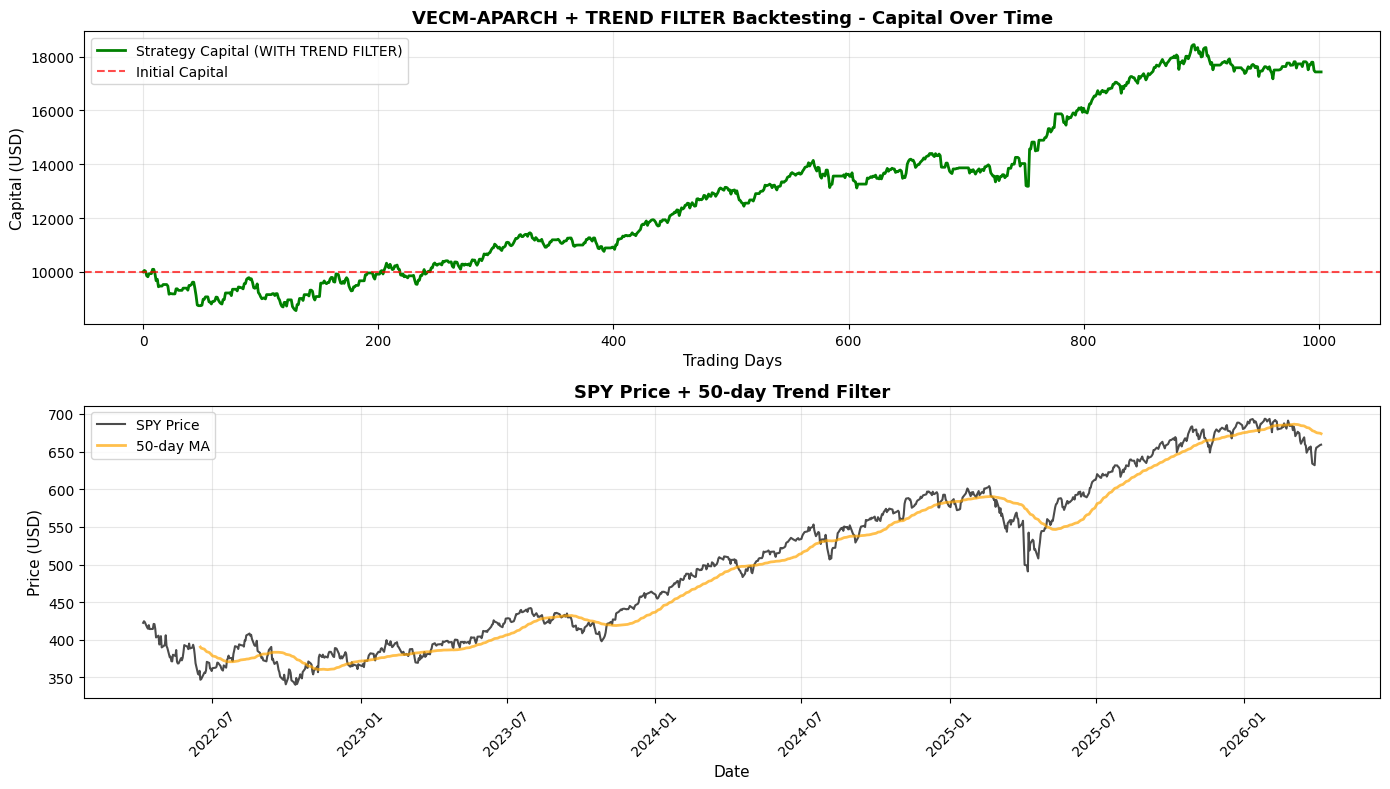

In [17]:
plt.figure(figsize=(14, 8))

# Plot 1: Strategy Capital Over Time
plt.subplot(2, 1, 1)
plt.plot(results, label='Strategy Capital (WITH TREND FILTER)', linewidth=2, color='green')
plt.axhline(y=INITIAL_CAPITAL, color='r', linestyle='--',
           label='Initial Capital', alpha=0.7)
plt.xlabel('Trading Days', fontsize=11)
plt.ylabel('Capital (USD)', fontsize=11)
plt.title('VECM-APARCH + TREND FILTER Backtesting - Capital Over Time',
         fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Plot 2: Price + Trend Filter
plt.subplot(2, 1, 2)
plt.plot(test_data.index, test_data[TARGET_INDEX].values,
        label=f'{TARGET_INDEX} Price', linewidth=1.5, color='black', alpha=0.7)
# Add 50-day MA
ma_50 = test_data[TARGET_INDEX].rolling(window=50).mean()
plt.plot(test_data.index, ma_50, label='50-day MA', linewidth=2, color='orange', alpha=0.7)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Price (USD)', fontsize=11)
plt.title(f'{TARGET_INDEX} Price + 50-day Trend Filter',
         fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()